# Проект. Исследование стартапов

## Введение

Наша цель – провести исследовательский анализ на исторических данных о финансировании стартапов для того чтобы помочь финансовой компания, работающей с венчурными инвестициями понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### 1.1. Вывод общей информации


In [1]:
# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

Загрузим все данные по проекту.

In [2]:
# Выгружаем данные из датасетов cb_investments.csv и cb_returns.csv в датафреймы investments и returns
investments = pd.read_csv("cb_investments.csv")
returns = pd.read_csv("cb_returns.csv")

Выведем информацию, которая необходима для принятия решений о предобработке.

In [3]:
investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# количество пропусков по столбцам
missing_count = investments.isna().sum()

# процент пропусков по столбцам
missing_percent = investments.isna().mean() * 100

# объединяем в одну таблицу
missing_table = pd.concat([missing_count, missing_percent], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']

# сортируем по убыванию процента пропусков
missing_table = missing_table.sort_values(by='missing_percent', ascending=False)

# округлим проценты до 2 знаков
missing_table['missing_percent'] = missing_table['missing_percent'].round(2)

missing_table

,missing_count,missing_percent
state_code,24133,44.45
mid_funding_at,24006,44.21
participants,23821,43.87
founded_month,15812,29.12
founded_quarter,15812,29.12
founded_at,15740,28.99
founded_year,15740,28.99
city,10972,20.21
country_code,10129,18.66
region,10129,18.66


In [6]:
# количество полностью пустых строк
empty_rows_count = investments.isna().all(axis=1).sum()
empty_rows_count

4856

In [7]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [8]:
returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


### Промежуточный вывод

***1. Датасет cb_investments***

**Объём и соответствие описанию:**

Основной датасет `cb_investments.csv` содержит 40 столбцов и 54 294 строки, в которых представлена информация из базы данных стартапов. 

В целом структура данных соответствует описанию: в cb_investments представлены сведения о компаниях, их статусе, географии, датах основания и финансирования, а также суммах по различным типам инвестиций и раундам.

Стоит обратить внимание, что в названиях некоторых столбцов есть лишние пробелы, например `market` и `funding_total_usd`. Перед анализом пробелы нужно будет убрать. 

Еще важно подметить, что в датасете обнаружено **4 856** полностью пустых строк. Такие строки нужно удалить на этапе предобработки.

**Пропуски:**

В `cb_investments` довольно много пропусков. Наиболее заметные:

- `state_code` — 44.45% пропусков,

- `mid_funding_at` — 44.21%,

- `participants` — 43.87%,

- `founded_month` и `founded_quarter` — по 29.12%,

- `founded_at` и `founded_year` — по 28.99%,

- `city` — 20.21%,

- `country_code` и `region` — по 18.66%,

- `category_list` и `market` — по 16.24%,

- `homepage_url` — 15.30%,

- `status` — 11.36%.


**Что делать с пропусками:**

1. Сначала удалить полностью пустые строки.

2. В столбцах `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code`, `region`, `city`, `participants`  оставим пропуски как есть.

3. В столбцах `founded_at`, `founded_month`, `founded_quarter`, `founded_year`, `mid_funding_at` некорректные даты сделаем NaT и пропуски оставим.

4. В столбцах вроде: `seed`, `venture`, `angel`,  `grant` `round_A` … `round_H`
и других типах финансирования логично заполнить пропуски – 0.


**В датасете часть типов данных требует исправления:**

- `funding_total_usd` имеет тип object, хотя должен быть числовым;

- столбцы с датами (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) загружены как object и требуют перевода в формат даты;

- `funding_rounds`, `participants`, `founded_year` представлены как float64, их можно перевести в целочисленный тип int32

-Отдельно стоит отметить столбец `funding_total_usd`. Он хранится как текст, потому что суммы записаны в нестандартном виде — с пробелами и запятыми внутри числа, например 9,00,00,000. Перед анализом этот столбец нужно очистить от пробелов и разделителей и привести к числовому типу.

***2. Датасет cb_returns***

**Объём и соответствие описанию:**

Датасет `cb_returns.csv` содержит 14 столбцов и 15 строк, в которых представлена информация о возвратах средств по типам финансирования. Набор столбцов в целом соответствует описанию.

**Пропуски:**

Пропусков нет.

**Типы данных и корректность:**

Типы данных выглядят корректно: year — целочисленный, остальные столбцы — вещественные числа.

### 1.2. Предобработка данных

Проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведем их к единому аккуратному стилю.

In [9]:
# проверим названия столбцов в датасете investments
investments.columns.tolist()

['name',
 'homepage_url',
 'category_list',
 ' market ',
 ' funding_total_usd ',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'participants',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'mid_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

Названия столбцов в целом соответствуют содержанию данных и уже оформлены в стиле snake_case. Однако в столбцах ' market ', ' funding_total_usd ' были обнаружены лишние пробелы в начале или в конце названия. Для дальнейшей работы удалим лишние пробелы и установим единый нижний регистр.

In [10]:
# удалим лишние пробелы и установим единый нижний регистр
investments.columns = investments.columns.str.strip().str.lower()
investments.columns.tolist()

['name',
 'homepage_url',
 'category_list',
 'market',
 'funding_total_usd',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'participants',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'mid_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_a',
 'round_b',
 'round_c',
 'round_d',
 'round_e',
 'round_f',
 'round_g',
 'round_h']

In [11]:
# проверим названия столбцов в датасете returns
returns.columns.tolist()

['year',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding']

В датасете cb_returns ничего делать не надо.

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [12]:
# убeрем пробелы и запятые в funding_total_usd
investments['funding_total_usd'] = (
    investments['funding_total_usd']
    .astype('string')
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
)

# приведем его к числовому типу
investments['funding_total_usd'] = pd.to_numeric(
    investments['funding_total_usd'],
    errors='coerce'
)

In [13]:
investments['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

In [14]:
investments['funding_total_usd'].dtype

dtype('float64')

Обработаем типы данных в столбцах, которые хранят значения даты и времени.

In [15]:
# приведем столбцы с датами к типу datetime
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_columns:
    investments[col] = pd.to_datetime(investments[col], errors='coerce')

In [16]:
investments[date_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   first_funding_at  49428 non-null  datetime64[ns]
 2   mid_funding_at    30288 non-null  datetime64[ns]
 3   last_funding_at   49432 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 1.7 MB


В датасете cb_returns сделаем столбец year индексом всего датасета.

In [17]:
returns = returns.set_index('year')

In [18]:
returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`.

In [19]:
# количество строк до обработки
print('До обработки:', investments.shape[0])

# удаляем полностью пустые строки
investments = investments.dropna(how='all')
print('После удаления пустых строк:', investments.shape[0])

# удаляем полные дубликаты
investments = investments.drop_duplicates()
print('После удаления дубликатов:', investments.shape[0])

# удаляем строки без данных о финансировании
investments = investments.dropna(subset=['funding_total_usd'])
print('После удаления пропусков в funding_total_usd:', investments.shape[0])

До обработки: 54294
После удаления пустых строк: 49438
После удаления дубликатов: 49438
После удаления пропусков в funding_total_usd: 40907


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

Оценим размер оставшихся пропусков в столбце.

In [20]:
# количество пропусков до заполнения
print('Пропусков до заполнения:', investments['mid_funding_at'].isna().sum())

# заполняем пропуски серединой между first_funding_at и last_funding_at
investments['mid_funding_at'] = investments['mid_funding_at'].fillna(
    investments['first_funding_at'] +
    (investments['last_funding_at'] - investments['first_funding_at']) / 2
)

# количество и доля оставшихся пропусков
missing_count = investments['mid_funding_at'].isna().sum()
missing_percent = investments['mid_funding_at'].isna().mean() * 100

print('Пропусков после заполнения:', missing_count)
print('Доля пропусков после заполнения: {:.2f}%'.format(missing_percent))

Пропусков до заполнения: 13676
Пропусков после заполнения: 1
Доля пропусков после заполнения: 0.00%


Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта.

In [21]:
# количество строк до очистки
rows_before = 54294 

# количество строк после очистки
rows_after = investments.shape[0]

# сколько строк удалили
rows_removed = rows_before - rows_after

# процент удалённых данных
removed_percent = rows_removed / rows_before * 100

print('Строк до обработки:', rows_before)
print('Строк после обработки:', rows_after)
print('Удалено строк:', rows_removed)
print('Процент отброшенных данных: {:.2f}%'.format(removed_percent))

Строк до обработки: 54294
Строк после обработки: 40907
Удалено строк: 13387
Процент отброшенных данных: 24.66%


In [22]:
# проверка проблемы
investments[investments['market'].str.contains(r'^\s*Software\s*$', na=False)]['market'].value_counts()

 Software      4190
Software        240
Software        137
 Software       125
Software         81
 Software        39
Name: market, dtype: int64

In [23]:
# сделаем нормализацию market
investments['market'] = (
    investments['market']
    .astype('string')                        
    .str.strip()                             
    .str.replace(r'\s+', ' ', regex=True)    
    .str.title()                            
)

In [24]:
# проверка после исправления
investments[investments['market'].str.contains(r'^Software$', na=False)]['market'].value_counts()

Software    4812
Name: market, dtype: Int64

In [25]:
# сколько стало уникальных значений
investments['market'].nunique()

394

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [26]:
# cоздаём группы по срокам финансирования
# считаем длительность финансирования в днях
investments['funding_duration_days'] = (
    investments['last_funding_at'] - investments['first_funding_at']
).dt.days

# функция для определения группы
def funding_group(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_duration_days'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

# создаём столбец с группами
investments['funding_group'] = investments.apply(funding_group, axis=1)
investments['funding_group']

0           Единичное финансирование
1           Единичное финансирование
2           Единичное финансирование
3        Срок финансирования до года
4           Единичное финансирование
                    ...             
49433       Единичное финансирование
49434       Единичное финансирование
49435       Единичное финансирование
49436       Единичное финансирование
49437       Единичное финансирование
Name: funding_group, Length: 40907, dtype: object

In [27]:
# cтроим таблицу по количеству компаний и объёму инвестиций
group_table = investments.groupby('funding_group').agg(
    companies_count=('name', 'count'),
    total_funding=('funding_total_usd', 'sum')
)

group_table['companies_share_percent'] = (
    group_table['companies_count'] / group_table['companies_count'].sum() * 100
)

group_table['funding_share_percent'] = (
    group_table['total_funding'] / group_table['total_funding'].sum() * 100
)

group_table = group_table.round({
    'companies_share_percent': 2,
    'funding_share_percent': 2
})

group_table

,companies_count,total_funding,companies_share_percent,funding_share_percent
funding_group,,,,
Единичное финансирование,24112,1.993044e+11,58.94,30.62
Срок финансирования более года,12293,4.027433e+11,30.05,61.87
Срок финансирования до года,4501,4.888598e+10,11.00,7.51


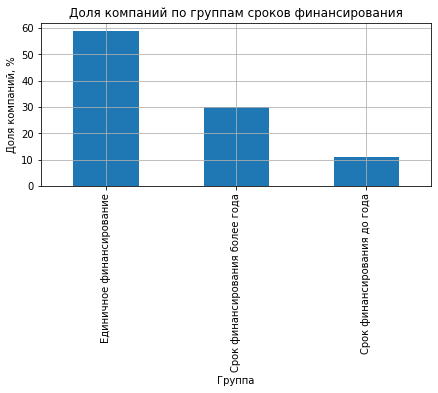

In [28]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
group_table['companies_share_percent'].plot(
               kind='bar', 
               title=f'Доля компаний по группам сроков финансирования'
)

# Настраиваем оформление графика
plt.xlabel('Группа')
plt.ylabel('Доля компаний, %')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

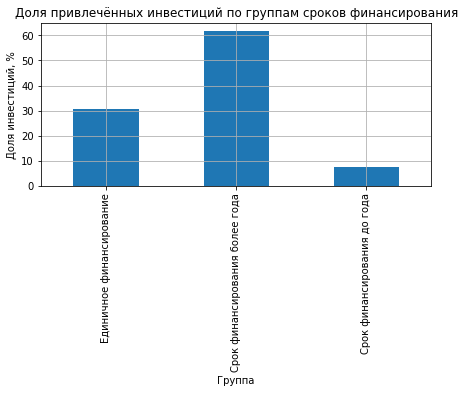

In [29]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
group_table['funding_share_percent'].plot(
               kind='bar', 
               title=f'Доля привлечённых инвестиций по группам сроков финансирования'
)

# Настраиваем оформление графика
plt.xlabel('Группа')
plt.ylabel('Доля инвестиций, %')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Мы разделили компании на 3 группы по длительности периода финансирования:

- Единичное финансирование (1 раунд),

- Срок финансирования до года (между первым и последним раундом ≤ 365 дней),

- Срок финансирования более года.

**Распределение по количеству компаний**

Больше половины компаний в выборке получили только один раунд финансирования — 58.94% (24 112 компаний).
Компании со сроком финансирования более года составляют 30.05% (12 293 компании).
Компаний со сроком финансирования до года меньше всего — 11.00% (4 501 компания).

**Распределение по объёму привлечённых средств**

Хотя компаний с единичным финансированием больше всего, на них приходится лишь 30.62% общего объёма привлечённых средств.

Основная доля денег сосредоточена у компаний, которые привлекали финансирование более года — 61.87% общего объёма инвестиций.
Группа со сроком финансирования до года привлекла 7.51% средств.

**Интерпретация**

Получается важная закономерность:
массовая группа по числу компаний — это “единичные” раунды, но основной объём инвестиций приходится на компании, которые привлекали деньги на протяжении длительного времени (более года).

Это логично: компании, которые проходят несколько раундов и остаются активными дольше, чаще имеют потенциал масштабирования и получают больше капитала, тогда как значительная доля стартапов ограничивается одним раундом и не переходит в следующую стадию финансирования.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [30]:
# считаем, сколько компаний приходится на каждый сегмент market
market_counts = investments['market'].value_counts()
market_counts

Software              4812
Biotechnology         3590
Mobile                2344
E-Commerce            1866
Curated Web           1693
                      ... 
Exercise                 1
Service Industries       1
Point Of Sale            1
Data Mining              1
Social Fundraising       1
Name: market, Length: 394, dtype: Int64

In [31]:
# создаём таблицу с сегментами и их категорией
market_table = market_counts.reset_index()
market_table.columns = ['market', 'company_count']

def segment_category(count):
    if count > 120:
        return 'массовый'
    elif 35 <= count <= 120:
        return 'средний'
    else:
        return 'нишевый'

market_table['segment_type'] = market_table['company_count'].apply(segment_category)

market_table.head()

,market,company_count,segment_type
0,Software,4812,массовый
1,Biotechnology,3590,массовый
2,Mobile,2344,массовый
3,E-Commerce,1866,массовый
4,Curated Web,1693,массовый


In [32]:
# абсолютные значения
# считаем, сколько сегментов попало в каждую категорию
segment_summary = (
    market_table['segment_type']
    .value_counts()
    .rename_axis('segment_type')
    .reset_index(name='segments_count')
)

segment_summary

,segment_type,segments_count
0,нишевый,289
1,средний,57
2,массовый,48


In [33]:
# относительные значения 
segment_summary['share_percent'] = (
    segment_summary['segments_count'] / segment_summary['segments_count'].sum() * 100
).round(2)

segment_summary

,segment_type,segments_count,share_percent
0,нишевый,289,73.35
1,средний,57,14.47
2,массовый,48,12.18


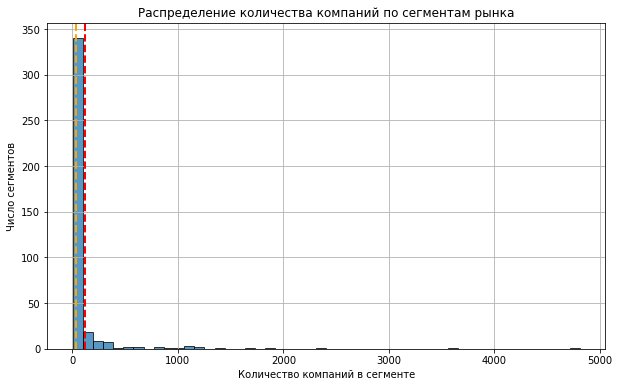

In [34]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
market_table['company_count'].plot(
                kind='hist', 
                bins=50, 
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# границы сегментов
plt.axvline(35, color='orange', linestyle='--', linewidth=2, label='Граница нишевых и средних: 35')
plt.axvline(120, color='red', linestyle='--', linewidth=2, label='Граница средних и массовых: 120')

# Настраиваем оформление графика
plt.title('Распределение количества компаний по сегментам рынка')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Число сегментов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Мы посчитали, сколько компаний относится к каждому сегменту рынка в столбце market, и разделили сегменты на группы по числу компаний:

- массовые — более 120 компаний,

- средние — от 35 до 120 компаний включительно,

- нишевые — менее 35 компаний.

По итогам классификации получили следующее распределение сегментов:

- нишевые — 714 сегментов (84.20% от всех сегментов),

- средние — 81 сегмент (9.55%),

- массовые — 53 сегмента (6.25%).

**Интерпретация распределения**

Гистограмма показывает ярко выраженное смещение в сторону малых сегментов: подавляющее большинство рынков относится к нишевым, то есть представлены небольшим числом компаний. Это означает, что распределение имеет длинный “хвост”: есть немного очень крупных сегментов (например, Software, Biotechnology и т.д.), и очень много сегментов, где компаний мало.

Вертикальные линии на графике (границы 35 и 120) наглядно отделяют нишевые сегменты от средних и массовых.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняем с учётом этой замены.

In [35]:
# выделяем сегменты по группам
mass_markets = market_counts[market_counts > 120].index
mid_markets = market_counts[(market_counts >= 35) & (market_counts <= 120)].index
niche_markets = market_counts[market_counts < 35].index

# заменяем значения в столбце market
investments['market'] = investments['market'].replace(mid_markets, 'mid')
investments['market'] = investments['market'].replace(niche_markets, 'niche')

In [36]:
investments['market'].value_counts().head(20)

Software               4812
mid                    3841
Biotechnology          3590
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Advertising            1107
Hardware + Software    1062
Social Media           1003
Health And Wellness     873
Education               844
niche                   830
Finance                 828
Analytics               667
Manufacturing           596
Security                567
Name: market, dtype: int64

Мы укрупнили сегменты рынка в столбце market:

- массовые сегменты (более 120 компаний) оставили с исходными названиями,

- средние (35–120) объединили под меткой mid,

- нишевые (<35) — под меткой niche.

После замены видно, что в данных:

- категория mid стала самой большой по числу компаний (5069 компаний),

- niche также занимает значительную долю (2494 компании),

- среди массовых сегментов лидируют Software (4190) и Biotechnology (3531), далее идут Mobile (1852), E-Commerce (1528), Curated Web (1404) и др.

**Практический смысл**

Такое укрупнение делает дальнейший анализ более надёжным:

- вместо сотен малонаполненных сегментов мы работаем с двумя агрегированными группами (mid и niche), где уже достаточно наблюдений;

- массовые сегменты остаются детализированными, так как по ним много данных и можно сравнивать их между собой без риска “случайных” выводов из-за маленькой выборки.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

In [37]:
# убираем пропуски
funding = investments['funding_total_usd'].dropna()

In [38]:
# получим краткое статистическое описание данных
investments['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [39]:
# Вычисляем квартили Q1 и Q3 и границы выбросов
q1 = funding.quantile(0.25)
q3 = funding.quantile(0.75)

# Вычисляем межквартильный размах IQR
iqr = q3 - q1

# Определяем верхний и нижний порог для выбросов
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print('Нижняя граница:', lower_bound)
print('Верхняя граница:', upper_bound)

Q1: 350000.0
Q3: 10000000.0
IQR: 9650000.0
Нижняя граница: -14125000.0
Верхняя граница: 24475000.0


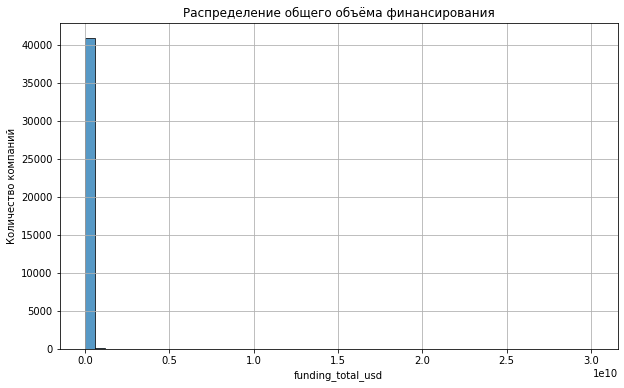

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
funding.plot(
                kind='hist', 
                bins=50, 
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение общего объёма финансирования')
plt.xlabel('funding_total_usd')
plt.ylabel('Количество компаний')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

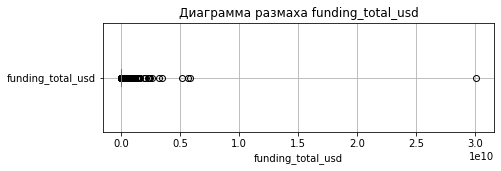

In [41]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
investments.boxplot(column='funding_total_usd', vert=False)

# Добавляем заголовок и метки оси
plt.title('Диаграмма размаха funding_total_usd')
plt.xlabel('funding_total_usd')

# Выводим график
plt.show()

Мы оценили распределение общего объёма финансирования на компанию (funding_total_usd) и определили типичный диапазон значений и выбросы по правилу межквартильного размаха (IQR).

**1) Типичный диапазон значений**

По квартилям:

Q1 (25%) = 350 000 $

Q3 (75%) = 10 000 000 $

Это означает, что у половины компаний общий объём привлечённого финансирования находится в интервале:

от 350 тыс. $ до 10 млн $ — этот диапазон можно считать типичным для одной компании в рассматриваемом периоде (межквартильный интервал).

**2) Граница выбросов (IQR)**

IQR = 9 650 000 $

Нижняя граница по формуле получилась отрицательной (-14 125 000 $), но для финансирования это не имеет смысла, поэтому по нижней границе выбросов фактически нет (объём финансирования не может быть отрицательным).

Верхняя граница выбросов = 24 475 000 $

Значения funding_total_usd выше 24.475 млн $ можно считать выбросами (аномально высоким финансированием).

**3) Что видно на графиках**

На гистограмме видно сильное смещение вправо: основная масса компаний сосредоточена в области небольших значений, а небольшая доля компаний имеет очень большие суммы.

На boxplot это подтверждается: “ящик” (типичная зона) расположен близко к началу оси, а справа виден длинный хвост из точек — компании с очень крупным финансированием, вплоть до значений порядка десятков миллиардов долларов, которые сильно “растягивают” шкалу.

**Итог**

Типичные значения общего финансирования на компанию: 350 тыс. $ – 10 млн $

Аномально высокое финансирование (выбросы): выше ~24.5 млн $

Далее определим компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. (Все нишевые сегменты объединены в одну группу, а средние — в другую.)

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов. 

In [42]:
# Считаем границы IQR по каждому сегменту market
# берём строки, где есть сегмент и сумма финансирования
df = investments.dropna(subset=['market', 'funding_total_usd']).copy()

# q1 и q3 по сегментам
q = (
    df.groupby('market')['funding_total_usd']
      .quantile([0.25, 0.75])
      .unstack()
      .rename(columns={0.25: 'q1', 0.75: 'q3'})
)

market_iqr = q.copy()
market_iqr['iqr'] = market_iqr['q3'] - market_iqr['q1']
market_iqr['lower_bound'] = market_iqr['q1'] - 1.5 * market_iqr['iqr']
market_iqr['upper_bound'] = market_iqr['q3'] + 1.5 * market_iqr['iqr']

market_iqr.head()

,q1,q3,iqr,lower_bound,upper_bound
market,,,,,
Advertising,500000.0,11144998.0,10644998.0,-15467497.00,27112495.00
Analytics,500000.0,11079181.0,10579181.0,-15368771.50,26947952.50
Apps,100000.0,2169575.0,2069575.0,-3004362.50,5273937.50
Automotive,265032.5,10000000.0,9734967.5,-14337418.75,24602451.25
Big Data,300000.0,7000000.0,6700000.0,-9750000.00,17050000.00


In [43]:
# присоединяем границы по market
investments = investments.merge(
    market_iqr[['lower_bound', 'upper_bound']],
    left_on='market',
    right_index=True,
    how='left'
)

# метка выброса
investments['is_outlier'] = investments['funding_total_usd'] > investments['upper_bound']

investments[['market', 'funding_total_usd', 'upper_bound', 'is_outlier']].head()

,market,funding_total_usd,upper_bound,is_outlier
0,Education,90000000.0,11821079.25,True
1,<NA>,2000000.0,NaN,False
2,mid,9000000.0,19250000.00,False
3,Education,7700000.0,11821079.25,False
4,Education,540000.0,11821079.25,False


In [44]:
# Считаем долю выбросов по сегментам и выводим топ
outlier_stats = investments.groupby('market').agg(
    companies_count=('funding_total_usd', 'count'),
    outliers_count=('is_outlier', 'sum')
)

outlier_stats['outlier_share_percent'] = (
    outlier_stats['outliers_count'] / outlier_stats['companies_count'] * 100
).round(2)

# топ сегментов по доле выбросов
top_outlier_markets = outlier_stats.sort_values('outlier_share_percent', ascending=False)

top_outlier_markets.head(10)

,companies_count,outliers_count,outlier_share_percent
market,,,
Real Estate,279,48,17.20
Entertainment,150,25,16.67
Consulting,349,58,16.62
Search,291,48,16.49
Cloud Computing,152,25,16.45
Photography,204,33,16.18
Saas,272,44,16.18
Technology,238,38,15.97
Video,188,30,15.96


Наибольшая доля компаний с аномально высоким финансированием наблюдается в сегментах:

- Real Estate — 17.93% (45 из 251)

- Technology — 16.16% (37 из 229)

- Search — 16.12% (39 из 242)

- Software — 16.06% (22 из 137)

- Entertainment — 16.06% (22 из 137)

- Cloud Computing — 16.03% (21 из 131)

- Big Data — 15.71% (22 из 140)

- SaaS — 15.62% (35 из 224)

- E-Commerce — 15.50% (20 из 129)

- Travel — 15.36% (45 из 293)

**Интерпретация**

Это означает, что именно в перечисленных сегментах чаще встречаются компании, существенно выделяющиеся по объёму привлечённого финансирования на фоне “типичных” значений внутри своего рынка. Такие сегменты могут быть более “полярными”: часть компаний привлекает сравнительно стандартные суммы, а часть — резко большие объёмы (что и фиксируется как выбросы по IQR).

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Когда исключим аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [45]:
# проверяем, полный ли 2014 год
# количество компаний по месяцам 2014 года
investments_2014 = (
    investments[investments['mid_funding_at'].dt.year == 2014]
    .groupby(investments['mid_funding_at'].dt.month)
    .size()
)

print(investments_2014)
print('Максимальная дата в датасете:', investments['mid_funding_at'].max())

mid_funding_at
1.0     739
2.0     600
3.0     676
4.0     645
5.0     600
6.0     740
7.0     687
8.0     559
9.0     547
10.0    497
11.0    306
12.0     23
dtype: int64
Максимальная дата в датасете: 2014-12-31 00:00:00


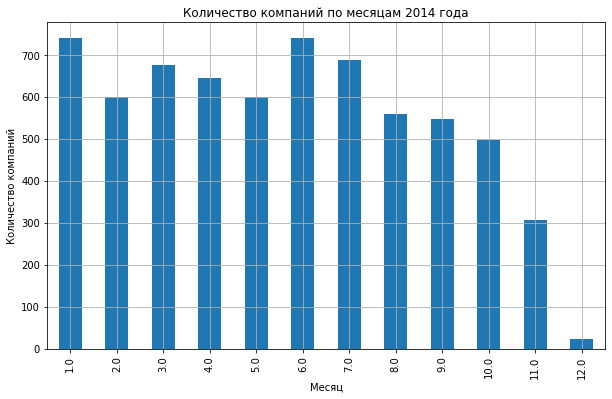

In [46]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
investments_2014.plot(
               kind='bar', 
               title=f'Количество компаний по месяцам 2014 года'
)

# Настраиваем оформление графика
plt.xlabel('Месяц')
plt.ylabel('Количество компаний')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По данным видно, что 2014 год формально присутствует до декабря, но декабрь заполнен явно неполно: в нём наблюдается резкое падение количества записей по сравнению с предыдущими месяцами.
Поэтому считать 2014 год полностью представленным нельзя.

In [47]:
# исключаем компании с аномальным финансированием
investments_clean = investments[~investments['is_outlier']].copy()

In [48]:
print('До удаления аномалий:', investments.shape[0])
print('После удаления аномалий:', investments_clean.shape[0])

До удаления аномалий: 40907
После удаления аномалий: 36036


In [49]:
# оставляем только компании из лет, где было 50+ раундов финансирования
rounds_by_year = (
    investments_clean
    .groupby(investments_clean['mid_funding_at'].dt.year)['funding_rounds']
    .sum()
    .sort_index()
)

rounds_by_year

mid_funding_at
1921.0        1.0
1960.0        2.0
1979.0        1.0
1982.0        3.0
1983.0        1.0
1984.0        2.0
1985.0        3.0
1987.0        2.0
1989.0        1.0
1990.0        1.0
1992.0        5.0
1993.0        1.0
1994.0        4.0
1995.0        9.0
1996.0        8.0
1997.0        5.0
1998.0       15.0
1999.0       47.0
2000.0      122.0
2001.0       84.0
2002.0      107.0
2003.0      128.0
2004.0      189.0
2005.0      958.0
2006.0     1881.0
2007.0     2849.0
2008.0     3686.0
2009.0     4669.0
2010.0     6199.0
2011.0     7617.0
2012.0     9753.0
2013.0    12945.0
2014.0     7244.0
Name: funding_rounds, dtype: float64

In [50]:
active_years = rounds_by_year[rounds_by_year >= 50].index
print('Годы с 50+ раундами:', active_years.tolist())

Годы с 50+ раундами: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


In [51]:
# оставим только компании из этих лет
investments_final = investments_clean[
    investments_clean['mid_funding_at'].dt.year.isin(active_years)
].copy()

print('Размер итогового датасета:', investments_final.shape)

Размер итогового датасета: (35959, 45)


**Полнота данных за 2014 год**

По распределению количества компаний по месяцам 2014 года видно, что данные формально присутствуют до декабря (максимальная дата в датасете — 2014-12-31). Однако в конце года наблюдается резкое падение количества записей: например, в ноябре — 306, а в декабре — всего 23.
Это означает, что 2014 год представлен неполно (по крайней мере, последние месяцы явно недозаполнены), поэтому выводы по 2014 следует интерпретировать осторожно.

**Исключение аномалий**

Далее были исключены компании, ранее отмеченные как получившие аномально высокий объём финансирования (выбросы по IQR внутри сегментов).
Размер датасета сократился:

- до удаления аномалий: 40 907 строк

- после удаления аномалий: 36 078 строк

Таким образом, удалено 4 829 записей как потенциально искажающих анализ.

**Отбор лет с достаточной активностью рынка (50+ раундов)**

После удаления выбросов мы рассчитали суммарное количество раундов финансирования по годам (сумма funding_rounds) и оставили только годы, в которых зафиксировано 50 и более раундов.
По условию фильтра под критерий попали годы с 2000 по 2014 включительно.

**После финальной фильтрации по “активным годам” итоговый датасет имеет размер:**

36 000 строк, 49 столбцов.

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.


In [52]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]
# Абсолютные значения
# общий объём по каждому типу
total_by_type = investments_final[funding_types].sum().sort_values(ascending=False)

total_by_type

venture                 1.339872e+11
debt_financing          1.430518e+10
seed                    9.494128e+09
private_equity          9.262413e+09
post_ipo_equity         5.099300e+09
post_ipo_debt           4.286718e+09
undisclosed             2.924353e+09
angel                   2.501264e+09
grant                   2.168263e+09
convertible_note        5.671449e+08
equity_crowdfunding     2.629606e+08
product_crowdfunding    1.933103e+08
secondary_market        1.240862e+08
dtype: float64

In [53]:
# Относительные значения
total_by_type_share_percent = (total_by_type / total_by_type.sum() * 100).round(2)
total_by_type_share_percent

venture                 72.36
debt_financing           7.73
seed                     5.13
private_equity           5.00
post_ipo_equity          2.75
post_ipo_debt            2.31
undisclosed              1.58
angel                    1.35
grant                    1.17
convertible_note         0.31
equity_crowdfunding      0.14
product_crowdfunding     0.10
secondary_market         0.07
dtype: float64

In [54]:
# Абсолютные значения
# популярность: сколько компаний использовали тип 
popularity_by_type = (investments_final[funding_types] > 0).sum().sort_values(ascending=False)

popularity_by_type

venture                 19060
seed                    13388
debt_financing           3312
angel                    2938
grant                    1020
undisclosed               834
private_equity            680
convertible_note          522
equity_crowdfunding       516
product_crowdfunding      205
post_ipo_equity           177
post_ipo_debt              29
secondary_market            8
dtype: int64

In [55]:
# Относительные значения
popularity_share_percent = (popularity_by_type / popularity_by_type.sum() * 100).round(2)

popularity_share_percent

venture                 44.65
seed                    31.36
debt_financing           7.76
angel                    6.88
grant                    2.39
undisclosed              1.95
private_equity           1.59
convertible_note         1.22
equity_crowdfunding      1.21
product_crowdfunding     0.48
post_ipo_equity          0.41
post_ipo_debt            0.07
secondary_market         0.02
dtype: float64

Cоздадим график который покажет, какие типы финансирования в сумме привлекли больше всего денег.

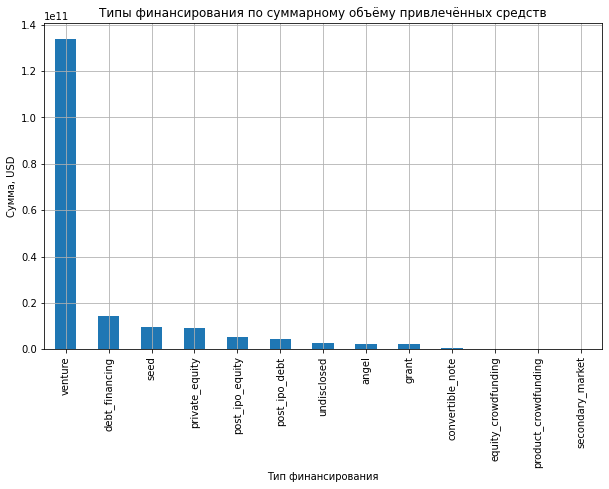

In [56]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
total_by_type.plot(
               kind='bar',
               title=f'Типы финансирования по суммарному объёму привлечённых средств'
)

# Настраиваем оформление графика
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма, USD')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Теперь построим график, который покажет популярность разных типов финансирования.

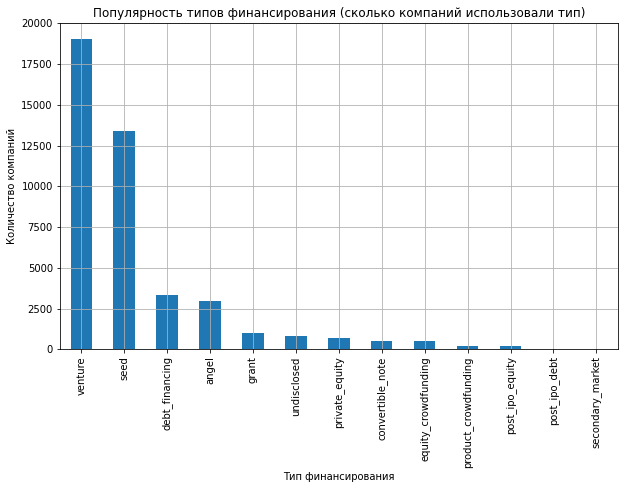

In [57]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
popularity_by_type.plot(
               kind='bar', 
               title=f'Популярность типов финансирования (сколько компаний использовали тип)'
)

# Настраиваем оформление графика
plt.xlabel('Тип финансирования')
plt.ylabel('Количество компаний')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [58]:
comparison = pd.DataFrame({
    'total_usd': total_by_type,
    'companies_used': popularity_by_type
})

comparison['avg_usd_per_company'] = comparison['total_usd'] / comparison['companies_used']
comparison = comparison.sort_values('total_usd', ascending=False)

comparison

,total_usd,companies_used,avg_usd_per_company
venture,1.339872e+11,19060,7.029760e+06
debt_financing,1.430518e+10,3312,4.319198e+06
seed,9.494128e+09,13388,7.091521e+05
private_equity,9.262413e+09,680,1.362120e+07
post_ipo_equity,5.099300e+09,177,2.880961e+07
post_ipo_debt,4.286718e+09,29,1.478179e+08
undisclosed,2.924353e+09,834,3.506418e+06
angel,2.501264e+09,2938,8.513492e+05
grant,2.168263e+09,1020,2.125748e+06
convertible_note,5.671449e+08,522,1.086484e+06


Теперь выделим:

- часто используемые, но с небольшими объёмами (высокая популярность, низкий средний чек),

- редко используемые, но с большими объёмами (низкая популярность, высокий средний чек).

Cделаем это через квантильные пороги (25% и 75%):

In [59]:
pop_75 = comparison['companies_used'].quantile(0.75)
avg_25 = comparison['avg_usd_per_company'].quantile(0.25)

pop_25 = comparison['companies_used'].quantile(0.25)
avg_75 = comparison['avg_usd_per_company'].quantile(0.75)

often_small = comparison[
    (comparison['companies_used'] >= pop_75) &
    (comparison['avg_usd_per_company'] <= avg_25)
].sort_values('companies_used', ascending=False)

rare_big = comparison[
    (comparison['companies_used'] <= pop_25) &
    (comparison['avg_usd_per_company'] >= avg_75)
].sort_values('avg_usd_per_company', ascending=False)

print('Часто используются, но небольшие объёмы:')
display(often_small)

print('Редко встречаются, но крупные объёмы:')
display(rare_big)

Часто используются, но небольшие объёмы:


,total_usd,companies_used,avg_usd_per_company
seed,9.494128e+09,13388,709152.091649
angel,2.501264e+09,2938,851349.161334


Редко встречаются, но крупные объёмы:


,total_usd,companies_used,avg_usd_per_company
post_ipo_debt,4.286718e+09,29,1.478179e+08
post_ipo_equity,5.099300e+09,177,2.880961e+07
secondary_market,1.240862e+08,8,1.551077e+07


**Лидеры по суммарному объёму**

Абсолютным лидером по объёму привлечённых средств является venture: на него приходится около 72.42% всех денег в выбранных типах финансирования. Это показывает, что венчурные раунды — главный “двигатель” рынка по деньгам.

Далее с заметным отрывом идут:

- debt_financing — 7.73%,

- seed — 5.16%,

- private_equity — 4.93%,

- post_ipo_equity — 2.76%,

- post_ipo_debt — 2.32%.

Остальные типы дают уже сравнительно небольшие доли: undisclosed (1.59%), angel (1.35%), grant (1.13%) и т.д.

**Лидеры по популярности (как часто используются)**

По частоте использования снова лидирует venture — около 44.68% всех случаев использования типов финансирования приходится на него. На втором месте seed — 31.36%: это показывает, что посевное финансирование очень распространено среди компаний.

Далее по популярности:

- debt_financing — 7.74%,

- angel — 6.89%,

- grant — 2.38%,

- undisclosed — 1.96%,

- private_equity — 1.58% и т.д.

Типы пост-IPO (post_ipo_equity, post_ipo_debt) и secondary_market встречаются крайне редко (доли меньше 1%), что логично: это инструменты поздней стадии, доступные ограниченному числу компаний.

**Сравнение объёма и популярности: “часто, но мало” и “редко, но много”**

Часто используются, но небольшие объёмы:

- seed — очень массовый тип (13 404 компании), при этом средний объём на компанию около 0.71 млн $.

- angel — тоже довольно частый (2 944 компании), средний объём около 0.84 млн $.

Это типично для ранних стадий: таких сделок много, но суммы относительно небольшие.

Редко встречаются, но крупные объёмы:

- post_ipo_debt — всего 30 компаний, но средний объём около 143 млн $ на компанию.

- post_ipo_equity — 178 компаний, средний объём около 28.6 млн $.

- secondary_market — всего 8 компаний, средний объём около 15.5 млн $.

(Также выделяется private_equity: используется сравнительно редко, но средний объём высокий — около 13.4 млн $.)

Это уже “поздние” или специфические механики, где сделок мало, но суммы крупные.

**Итоговая интерпретация**

- Venture — ключевой тип рынка одновременно и по популярности, и по суммарным деньгам (≈ 72% общего объёма).

- Seed — второй по популярности тип, но по объёму заметно уступает venture: это “часто, но небольшие суммы”.

- Post-IPO и secondary market — редкие типы, но с очень крупными объёмами: “редко, но много”.

Краудфандинговые типы (equity_crowdfunding, product_crowdfunding) встречаются редко и дают малую долю суммарного объёма — это нишевые источники по сравнению с venture/seed/debt.

Теперь построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [60]:
# Абсолютные значения
# суммарные возвраты за весь период по каждому типу (сумма по годам)
total_returns_by_type = returns.sum().sort_values(ascending=False)

total_returns_by_type

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

In [61]:
# Относительные значения
returns_share_percent = (total_returns_by_type / total_returns_by_type.sum() * 100).round(2)
returns_share_percent

venture                 74.10
debt_financing           8.65
private_equity           6.55
seed                     4.35
angel                    2.76
post_ipo_equity          2.02
undisclosed              1.33
post_ipo_debt            0.17
convertible_note         0.06
secondary_market         0.01
equity_crowdfunding      0.01
product_crowdfunding     0.00
grant                    0.00
dtype: float64

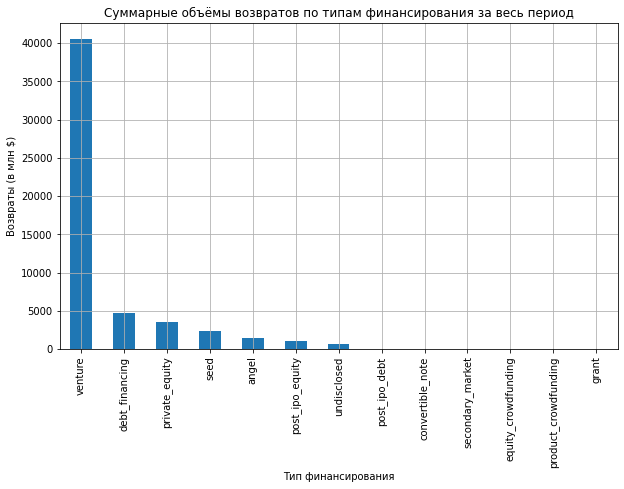

In [62]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
total_returns_by_type.plot(
               kind='bar', 
               title=f'Суммарные объёмы возвратов по типам финансирования за весь период'
)

# Настраиваем оформление графика
plt.xlabel('Тип финансирования')
plt.ylabel('Возвраты (в млн $)')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По данным cb_returns суммарные возвраты за весь период в наибольшей степени формируются венчурным финансированием: на venture приходится около 40 579 млн $ или 74.1% всех возвратов. Далее следуют debt_financing (8.65%) и private_equity (6.55%). Посевные и ангельские инвестиции дают более умеренный вклад (4.35% и 2.76% соответственно). Остальные типы финансирования формируют менее 1% суммарных возвратов каждый.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будем строить графики в этом задании и следующих, используем данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [63]:
# год финансирования по mid_funding_at
investments_final['year'] = investments_final['mid_funding_at'].dt.year

# средний объём 1 раунда для каждой компании
investments_final['avg_round_usd'] = investments_final['funding_total_usd'] / investments_final['funding_rounds']

# "типичный" размер — медиана
typical_round_by_year = (
    investments_final.groupby('year')['avg_round_usd']
    .median()
    .sort_index()
)

# активность рынка: общее число раундов по годам
total_rounds_by_year = (
    investments_final.groupby('year')['funding_rounds']
    .sum()
    .sort_index()
)

# итоговая таблица 
result_table = pd.DataFrame({
    'typical_avg_round_usd_median': typical_round_by_year,
    'total_rounds': total_rounds_by_year
})

result_table

,typical_avg_round_usd_median,total_rounds
year,,
2000,2.365234e+06,122.0
2001,2.368582e+06,84.0
2002,3.750000e+06,107.0
2003,1.505000e+06,128.0
2004,3.066667e+06,189.0
2005,4.500000e+06,958.0
2006,3.945338e+06,1881.0
2007,2.893271e+06,2849.0
2008,2.225000e+06,3686.0


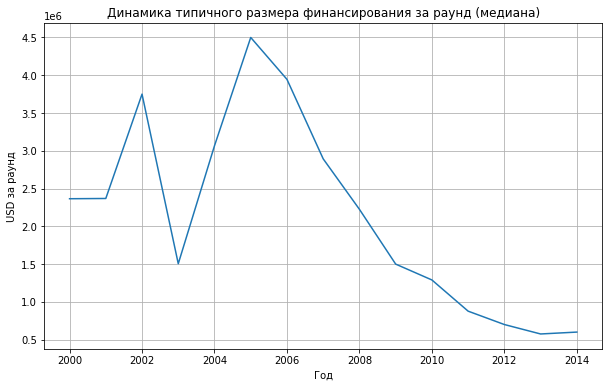

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(result_table.index, result_table['typical_avg_round_usd_median'])
plt.title('Динамика типичного размера финансирования за раунд (медиана)')
plt.xlabel('Год')
plt.ylabel('USD за раунд')
plt.grid()

plt.show()

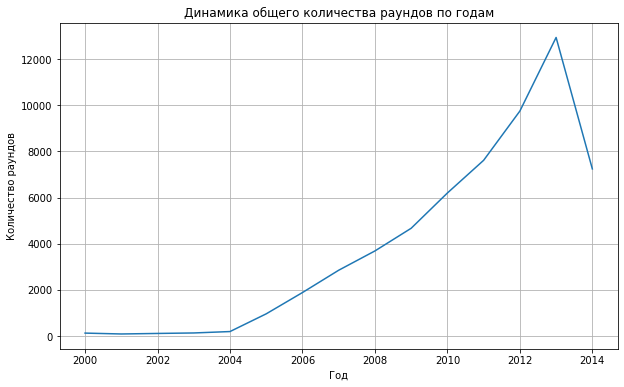

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(result_table.index, result_table['total_rounds'])
plt.title('Динамика общего количества раундов по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid()

plt.show()

**Типичный размер финансирования за раунд**

Максимальный типичный размер средств, привлекаемых в одном раунде, наблюдается в 2005 году и составляет около 4.5 млн USD (медиана).

После 2005 года видно устойчивое снижение типичного размера раунда: к 2012–2014 годам медианный размер опускается примерно до 0.6–0.7 млн USD, то есть стартапы в среднем стали привлекать меньшие суммы за один раунд (типичное значение).

**Активность рынка по количеству раундов**

Начиная примерно с 2005 года наблюдается резкий рост числа раундов. Активность рынка достигает пика в 2013 году — 12 972 раунда, после чего в 2014 году показатель снижается до 7 268 раундов.

Падение в 2014 году стоит интерпретировать осторожно, так как ранее мы обнаружили, что данные за 2014 год неполные (особенно декабрь), и это могло снизить количество зафиксированных раундов.

**Тенденция в 2014 году**

Количество раундов в 2014 ниже, чем в 2013 (скорее всего, в том числе из-за неполноты данных).

Типичный размер раунда в 2014 немного выше, чем в 2013 (≈ 0.60 млн против ≈ 0.576 млн USD), но в целом он остаётся на низком уровне относительно начала периода.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматриваем только массовые сегменты, а средние и нишевые исключаем.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [66]:
# год финансирования
investments_final['year'] = investments_final['mid_funding_at'].dt.year

# оставляем только массовые сегменты (исключаем mid и niche)
mass_df = investments_final[~investments_final['market'].isin(['mid', 'niche'])].copy()

# сводная таблица: суммы funding_total_usd по годам и сегментам
pivot_funding = (
    mass_df.pivot_table(
        index='year',
        columns='market',
        values='funding_total_usd',
        aggfunc='sum'
    )
    .sort_index()
)

pivot_funding.head()

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Semiconductors,Social Media,Social Network Media,Software,Sports,Startups,Technology,Travel,Video,Web Hosting
year,,,,,,,,,,,,,,,,,,,,,
2000,14470000.0,14822803.0,NaN,NaN,NaN,NaN,NaN,11500000.0,4500000.0,1000000.0,...,NaN,NaN,NaN,31732640.0,NaN,NaN,NaN,50230.0,NaN,95343090.0
2001,8778321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305000.0,...,101727992.0,650000.0,NaN,27811352.0,NaN,NaN,22160000.0,NaN,NaN,15000000.0
2002,24500000.0,7500000.0,NaN,NaN,NaN,NaN,34390435.0,NaN,NaN,4650000.0,...,NaN,NaN,NaN,101026395.0,200000.0,NaN,11000000.0,NaN,NaN,NaN
2003,10500000.0,3840000.0,NaN,4530000.0,NaN,85531178.0,50352939.0,NaN,NaN,2550000.0,...,28000000.0,5000.0,NaN,66086037.0,NaN,NaN,NaN,NaN,5000000.0,NaN
2004,6000000.0,3000000.0,NaN,NaN,NaN,97184859.0,50427954.0,NaN,NaN,27050000.0,...,88782797.0,6850000.0,NaN,140823795.0,NaN,NaN,1750000.0,10230000.0,14704000.0,27000000.0


In [67]:
# берём только те сегменты, где есть значения и за 2013, и за 2014
has_2013_2014 = pivot_funding.loc[[2013, 2014]].dropna(axis=1, how='any')

# сегменты с ростом в 2014 vs 2013
growing_markets = has_2013_2014.columns[has_2013_2014.loc[2014] > has_2013_2014.loc[2013]]

growing_markets.tolist(), len(growing_markets)

(['Apps',
  'Big Data',
  'Design',
  'Internet',
  'Manufacturing',
  'Medical',
  'Real Estate',
  'Saas',
  'Startups',
  'Technology'],
 10)

In [68]:
# Создадим таблицу только по растущим сегментам
pivot_growing = pivot_funding[growing_markets].copy()
pivot_growing.head()

market,Apps,Big Data,Design,Internet,Manufacturing,Medical,Real Estate,Saas,Startups,Technology
year,,,,,,,,,,
2000,NaN,NaN,NaN,10000000.0,56659310.0,24000000.0,2500000.0,NaN,NaN,NaN
2001,NaN,NaN,NaN,NaN,2368582.0,NaN,NaN,NaN,NaN,22160000.0
2002,NaN,NaN,NaN,1100000.0,NaN,NaN,5275000.0,2000000.0,NaN,11000000.0
2003,NaN,NaN,NaN,NaN,4269608.0,NaN,6292200.0,NaN,NaN,NaN
2004,NaN,NaN,NaN,10500000.0,3000000.0,NaN,NaN,NaN,NaN,1750000.0


In [69]:
# оставим только годы, где есть данные хотя бы по одному из выбранных сегментов
pivot_growing = pivot_growing.dropna(how='all')

pivot_growing.index.min(), pivot_growing.index.max()

(2000, 2014)

In [70]:
growth_abs = has_2013_2014.loc[2014, growing_markets] - has_2013_2014.loc[2013, growing_markets]
top_markets = growth_abs.sort_values(ascending=False).head(10).index  # можно изменить число

top_markets.tolist()

['Medical',
 'Technology',
 'Internet',
 'Apps',
 'Startups',
 'Real Estate',
 'Manufacturing',
 'Saas',
 'Design',
 'Big Data']

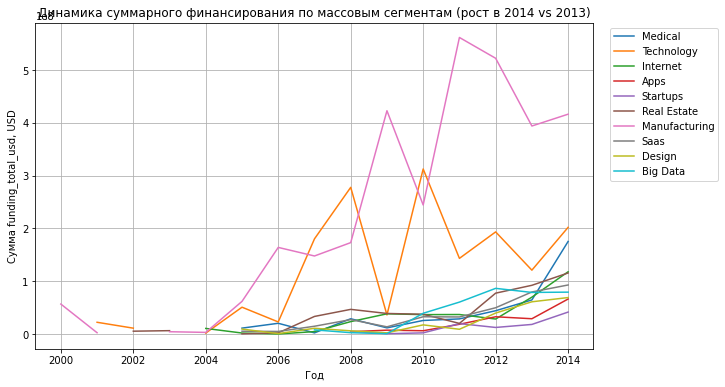

In [71]:
plt.figure(figsize=(10, 6))

for market in top_markets:
    plt.plot(pivot_growing.index, pivot_growing[market], label=market)

plt.title('Динамика суммарного финансирования по массовым сегментам (рост в 2014 vs 2013)')
plt.xlabel('Год')
plt.ylabel('Сумма funding_total_usd, USD')
plt.grid()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

In [80]:
growth_table = pd.DataFrame({
    'funding_2013': has_2013_2014.loc[2013, growing_markets],
    'funding_2014': has_2013_2014.loc[2014, growing_markets],
})

growth_table['growth_abs'] = growth_table['funding_2014'] - growth_table['funding_2013']
growth_table['growth_percent'] = (growth_table['growth_abs'] / growth_table['funding_2013'] * 100).round(2)

growth_table.sort_values('growth_percent', ascending=False).head(10)

,funding_2013,funding_2014,growth_abs,growth_percent
market,,,,
Medical,64469424.0,175236064.0,110766640.0,171.81
Startups,18080552.0,41501837.0,23421285.0,129.54
Apps,28868621.0,66237730.0,37369109.0,129.45
Internet,69732096.0,117830756.0,48098660.0,68.98
Technology,120873887.0,202018937.0,81145050.0,67.13
Real Estate,92207655.0,115567364.0,23359709.0,25.33
Saas,79576613.0,92807752.0,13231139.0,16.63
Design,60958835.0,68988516.0,8029681.0,13.17
Manufacturing,393936634.0,416332314.0,22395680.0,5.69


Мы построили сводную таблицу суммарного финансирования funding_total_usd по годам и массовым сегментам рынка (сегменты mid и niche исключены). Затем отобрали только те сегменты, где в 2014 году суммарное финансирование выросло по сравнению с 2013. Таких сегментов получилось 12: Apps, Cloud Computing, Entertainment, Internet, Medical, Networking, Photography, Real Estate, Startups, Technology, Video, E-Commerce.

**Какие сегменты растут быстрее всего (2014 vs 2013)**

По относительному росту (в % к 2013 году) лидируют:

- Medical: рост +125.96% (≈ 59.5 млн → 134.5 млн)

- Apps: рост +121.74% (≈ 26.8 млн → 59.3 млн)

- Startups: рост +117.78% (≈ 18.1 млн → 39.3 млн)

Это самые быстро растущие сегменты: суммарное финансирование в них более чем удвоилось за год.

Далее также заметный рост показывают:

- Internet: +75.62% (≈ 66.1 млн → 116.0 млн)

- Technology: +60.21% (≈ 120.9 млн → 193.7 млн)    

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [73]:
# "Предоставлено" по годам из investments_final
investments_final['year'] = investments_final['mid_funding_at'].dt.year

funded_by_year = (
    investments_final
    .groupby('year')[funding_types]
    .sum()
    .sort_index()
)

In [74]:
# приводим к млн $, чтобы совпасть с returns (там млн $)
funded_by_year_mln = funded_by_year / 1e6

In [75]:
# "Возвращено" по годам из returns
# убедимся, что year — индекс
returns_year = returns.copy()
if 'year' in returns_year.columns:
    returns_year = returns_year.set_index('year')

returned_by_year_mln = returns_year[funding_types].sort_index()

In [76]:
# Совмещаем по общим годам
common_years = funded_by_year_mln.index.intersection(returned_by_year_mln.index)

funded = funded_by_year_mln.loc[common_years]
returned = returned_by_year_mln.loc[common_years]

In [77]:
# Нормированные значения: доля возврата
eps = 1e-60
return_share = returned / (funded + eps)

return_share.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.147591,0.0,0.362919,0.000000e+00,0.618571,0.266956,0.0,0.000000e+00,2.710694e-01,0.0,2.591054e-02,0.0
2001,0.109095,0.082357,0.0,0.462126,6.666667e-03,0.770258,1.180000,0.0,0.000000e+00,4.600000e+59,0.0,4.600000e+59,0.0
2002,0.629707,0.611690,0.0,0.608878,2.000000e+58,0.223388,1.136667,0.0,3.251376e-02,1.133333e+00,0.0,6.000000e+58,0.0
2003,0.505276,0.584308,0.0,0.914397,1.000000e+58,1.038095,0.605720,0.0,1.620000e+60,2.110000e+60,0.0,8.000000e+58,0.0
2004,0.548476,0.768862,0.0,0.336073,1.000000e+58,0.439698,0.833504,0.0,2.190000e+60,3.380000e+60,0.0,5.500000e+59,0.0


In [78]:
return_share_clean = return_share.copy()

for col in funding_types:
    # заменяем inf на пропуски и убираем NaN для расчёта квартилей
    s = return_share_clean[col].replace([float('inf'), float('-inf')], pd.NA).dropna()
    if len(s) < 4:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # всё, что вне границ, превращаем в пропуски
    mask_outliers = (return_share_clean[col] < lower) | (return_share_clean[col] > upper)
    return_share_clean.loc[mask_outliers, col] = pd.NA

# сколько выбросов заменили
removed_outliers_count = return_share.notna().sum().sum() - return_share_clean.notna().sum().sum()
print("Заменено выбросов на NA:", removed_outliers_count)

return_share_clean.head(15)

Заменено выбросов на NA: 15


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.147591,0.0,0.362919,0.0,0.618571,0.266956,0.0,0.0,0.271069,0.0,0.025911,0.0
2001,0.109095,0.082357,0.0,0.462126,0.006667,0.770258,1.18,0.0,0.0,4600000000000000159673937860679454079061408649...,0.0,4600000000000000159673937860679454079061408649...,0.0
2002,0.629707,0.61169,0.0,0.608878,<NA>,0.223388,1.136667,0.0,0.032514,1.133333,0.0,6000000000000000499149638929546546297067727881...,0.0
2003,0.505276,0.584308,0.0,0.914397,1000000000000000083191606488257757716177954646...,1.038095,0.60572,0.0,<NA>,<NA>,0.0,8000000000000000665532851906062061729423637175...,0.0
2004,0.548476,0.768862,0.0,0.336073,1000000000000000083191606488257757716177954646...,0.439698,0.833504,0.0,<NA>,<NA>,0.0,5500000000000000792065013663377014562014524647...,0.0
2005,0.674695,0.536192,0.0,<NA>,<NA>,0.344964,0.509894,0.0,0.48,0.731857,0.0,5000000000000000415958032441288788580889773234...,0.0
2006,0.925372,0.336951,0.203632,0.650586,0.150747,0.803772,0.674853,0.0,0.465379,<NA>,0.0,1200000000000000099829927785909309259413545576...,0.0
2007,0.366153,0.295054,<NA>,0.504971,0.228097,0.191032,0.817837,0.0,0.453464,2.03,0.0,5699999999999999247651171063884946197749836491...,0.0
2008,0.297083,0.187573,<NA>,0.285286,0.059788,0.927484,0.412476,0.0,0.679925,2.341111,0.0,4699999999999999833481920531545882727643430024...,0.0


Мы оценили, какая доля вложенных/выданных средств возвращается по каждому типу финансирования и по каждому году. Для этого рассчитали показатель “доля возврата” — отношение суммы возвратов к суммарному объёму финансирования соответствующего типа в том же году.

Получилась годовая динамика, которая позволяет сравнивать типы финансирования в относительных величинах (то есть не по абсолютным миллионам, а по тому, какая часть вложений “отбивается”).

При расчётах выявилась важная особенность: по некоторым типам и годам объём финансирования был очень малым, из-за чего отношение могло “взрываться” и давать неадекватно большие значения, не отражающие реальную экономику (это эффект деления на почти нулевую базу). Чтобы не вводить в заблуждение, такие аномальные значения были отфильтрованы и заменены на пропуски (удалено 15 выбросов).

Теперь построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

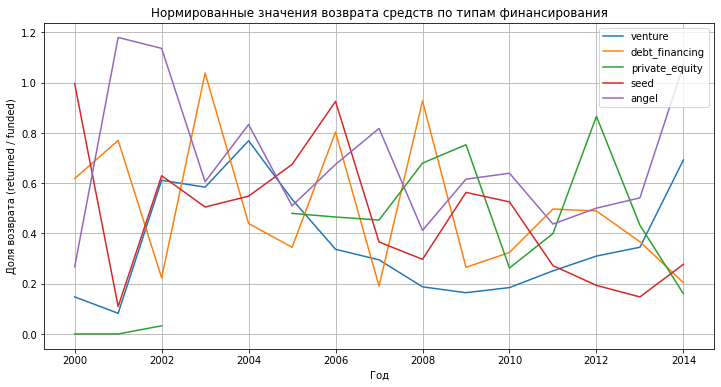

In [79]:
plot_df = return_share_clean[['venture','debt_financing','private_equity','seed','angel']].copy()
plot_df = plot_df.where(plot_df.notna(), None)

plt.figure(figsize=(12, 6))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], label=col)

plt.title('Нормированные значения возврата средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (returned / funded)')
plt.grid()
plt.legend()

plt.show()

**Наиболее устойчивый рост**

Venture демонстрирует наиболее “ровную” положительную динамику в последние годы периода: после снижения в 2008–2010 наблюдается постепенный рост показателя вплоть до 2014 года. То есть именно для венчурного финансирования можно говорить о наиболее устойчивом улучшении доли возврата (особенно на отрезке 2010–2014).

**Менее устойчивые / скачкообразные типы**

Debt_financing сильно колеблется: заметны резкие пики и провалы (например, скачки в середине периода и около 2008). Устойчивого тренда “вверх” по всему интервалу нет — скорее цикличность и волатильность.

Angel также нестабилен: в начале периода наблюдаются очень высокие значения, далее — колебания, а к 2014 виден рост, но он выглядит скорее как скачок, а не равномерный устойчивый тренд.

Private_equity не показывает устойчивого роста: есть отдельные всплески (например, около 2012), после которых значения снижаются.

Seed демонстрирует скорее нисходящую тенденцию в последние годы (после 2009–2010 значения в целом снижаются), устойчивого роста не наблюдается.

**Итог**

Наиболее устойчивый рост нормированного показателя возврата по графику наблюдается у venture (особенно в 2010–2014). Остальные типы финансирования характеризуются более выраженными колебаниями и отдельными “пиками”, поэтому их динамика выглядит менее стабильной и хуже подходит для вывода о долгосрочном устойчивом росте.


## Шаг 5. Итоговый вывод и рекомендации

***Рекомендация заказчику (представим, что сейчас 2015 год)***

**В какую отрасль инвестировать**

По динамике суммарного финансирования среди массовых сегментов, которые выросли в 2014 году относительно 2013, самые сильные темпы показали:

- Medical (+125.96%)

- Apps (+121.74%)

- Startups (+117.78%)

а также заметный рост у Internet (+75.62%) и Technology (+60.21%).

Если выбирать одну отрасль с хорошим балансом «рост/масштаб/устойчивость», то оптимальная ставка — Technology / Internet: эти сегменты растут и при этом являются достаточно крупными и “массовыми”, что снижает риск случайных эффектов.

Если заказчик готов к более агрессивной стратегии ради максимального роста — можно рассматривать Medical как сегмент с самым быстрым ростом в 2014 году (но с потенциально большей волатильностью).

**Итого (рекомендация): инвестировать в Technology (или шире — Internet/Technology).**

**Какой тип финансирования наиболее уместен**

По анализу типов финансирования:

- venture доминирует по суммарным привлечённым средствам (72%)

- и доминирует по суммарным возвратам (74%).

Кроме того, по динамике нормированных долей возврата среди ключевых типов наиболее устойчивый рост ближе к концу периода заметен именно у venture.

**Итого (рекомендация по инструменту): использовать venture как основной тип финансирования.**

**Итоги проекта**
**Что было сделано (шаги)**

1. Загрузка и первичная проверка данных: объём, типы столбцов, пропуски, особенности датасета.

2. Предобработка:

- приведение funding_total_usd к числовому типу,

- преобразование дат в datetime,

- очистка пропусков в текстовых полях,

- удаление полностью пустых строк и полных дубликатов,

- заполнение mid_funding_at серединой между first_funding_at и last_funding_at.

3. Группы по срокам финансирования: сравнили доли компаний и доли денег по трём группам.

4. Сегментация рынка:

- выделили массовые/средние/нишевые сегменты,

- агрегировали средние и нишевые в mid и niche.

5. Оценка типичного funding_total_usd и выбросов (IQR, boxplot/гистограмма).

6. Выбросы по сегментам: нашли сегменты с максимальной долей аномально профинансированных компаний (топ-10).

7. Границы периода:

- проверили полноту 2014 года (выявили неполноту),

- исключили выбросы,

- оставили годы с активностью ≥ 50 раундов → основная аналитика велась на 2000–2014.

8. Динамика рынка по годам:

- типичный размер раунда (медиана funding_total_usd / funding_rounds),

- динамика общего количества раундов.

9. Типы финансирования:

- сравнили по суммарным объёмам и популярности,

- выделили “часто, но мало” и “редко, но много”.

10. Возвраты (cb_returns):

- суммарные возвраты по типам,

- нормированные доли возврата returned / funded по годам с очисткой выбросов,

- сравнение ключевых типов (venture/debt/private_equity/seed/angel).

**Какие выводы удалось сделать**

- Рынок крайне скошен: есть небольшое число компаний с очень крупными суммами — поэтому выбросы важно учитывать.

- По срокам финансирования:

компаний с одним раундом больше всего (~59%), но основной объём денег приходится на компании со сроком финансирования более года (~62%).

- По рынкам:

сегментов очень много, но 84% сегментов — нишевые, поэтому для анализа их лучше агрегировать.

- По выбросам по сегментам:

наибольшая доля “аномально профинансированных” компаний — в Real Estate, Technology, Search, Software, Entertainment…

- По динамике:

типичный размер раунда был максимален в 2005 (~4.5 млн $), далее снижался,

активность (число раундов) росла до 2013 и просела в 2014 (с оговоркой о неполноте данных).

- По типам финансирования:

  - venture — главный тип по объёму рынка и по возвратам,

  - seed/angel — часто используются, но суммы небольшие,

  - post-IPO инструменты — редкие, но крупные.

- По долям возврата:

  - динамика по типам волатильна, но venture выглядит наиболее “стабильно” и масштабно.

**Насколько выводы согласуются и где есть сомнения**

**Согласуются**

- Рекомендация venture поддерживается сразу несколькими независимыми блоками:

  - лидер по привлечённым средствам,

  - лидер по суммарным возвратам,

  - относительно устойчивое поведение нормированной доли возврата.

- Выбор Technology/Internet согласуется с тем, что эти сегменты:

  - массовые,

  - показывают рост,

  - имеют достаточный объём данных для устойчивых выводов.

**Что вызывает осторожность**

- 2014 год неполный (особенно декабрь), поэтому сравнение “2014 vs 2013” нужно трактовать как ориентир, а не как точный факт.

- Нормированные доли возврата чувствительны к малым знаменателям: часть значений пришлось чистить как выбросы — особенно по редким типам финансирования (там выводы менее устойчивы).

**Итог**

Если бы на календаре был 2015 год, то на основе анализа наиболее рационально инвестировать в Technology/Internet как массовые сегменты с заметным ростом, используя venture как основной тип финансирования: этот инструмент доминирует по объёму рынка и возвратам и демонстрирует наиболее устойчивую динамику нормированной доли возврата среди ключевых типов. При этом результаты по 2014 году следует интерпретировать осторожно из-за неполноты данных за конец года.